In [24]:
# ==========================================
# ⚙️ Cell 1: 全局引擎初始化与数据加载 (Module 1 & 3 & Load)
# ==========================================
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. 核心主题配置 (原 Module 1)
# ---------------------------------------------------------
def setup_cs2_theme():
    warnings.filterwarnings('ignore')
    plt.style.use('dark_background')
    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei'] 
    plt.rcParams['axes.unicode_minus'] = False
    cs2_palette =["#00E5FF", "#FF4500", "#00FF00", "#FF00FF", "#FFFF00"]
    sns.set_palette(cs2_palette)
    sns.set_context("notebook", font_scale=1.1)
    theme_params = {
        'axes.facecolor': '#121212', 'figure.facecolor': '#0a0a0a', 
        'grid.color': '#333333', 'grid.linestyle': '--', 'axes.edgecolor': '#555555',
        'text.color': '#E0E0E0', 'axes.labelcolor': '#E0E0E0',
        'xtick.color': '#A0A0A0', 'ytick.color': '#A0A0A0'
    }
    plt.rcParams.update(theme_params)
    print("🎨 [System] CS2 Cyberpunk Theme Engine Initialized.")

# ---------------------------------------------------------
# 2. 绘图工厂函数 (原 Module 3)
# ---------------------------------------------------------
def plot_cs2_bar(ax, data, x_col, y_col=None, title="", color_palette="cool", orient='v', annotate=True):
    if orient == 'v':
        sns.barplot(data=data, x=x_col, y=y_col, palette=color_palette, ax=ax, edgecolor='#121212')
    else:
        sns.barplot(data=data, x=x_col, y=y_col, palette=color_palette, ax=ax, edgecolor='#121212', orient='h')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    sns.despine(ax=ax, left=True, bottom=True)
    if annotate and orient == 'v':
        for p in ax.patches:
            height = p.get_height()
            if not np.isnan(height) and height > 0:
                ax.annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='bottom', fontsize=12, fontweight='bold', color='white', 
                            xytext=(0, 5), textcoords='offset points')

def plot_cs2_pie(ax, series_data, title="", palette_name="Set2"):
    colors = sns.color_palette(palette_name, len(series_data))
    
    # 魔法逻辑：如果比例小于 4%，就不在图上挤文字了，保持清爽
    def custom_autopct(pct):
        return ('%1.1f%%' % pct) if pct >= 4.0 else ''
    
    wedges, texts, autotexts = ax.pie(
        series_data, labels=None, autopct=custom_autopct, startangle=90, 
        colors=colors, wedgeprops={'edgecolor': 'black', 'linewidth': 2}
    )
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(13)
        
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    # 把详细标签移到图表右侧，清晰明了！
    ax.legend(wedges, series_data.index, title="Categories", loc="center left", 
              bbox_to_anchor=(1, 0, 0.5, 1), facecolor='#121212', edgecolor='#555555', labelcolor='white')

def plot_cs2_hist(ax, data_series, title="", color="#00E5FF", bins=20, show_stats=False):
    sns.histplot(data_series, bins=bins, kde=True, color=color, edgecolor='#121212', ax=ax)
    ax.set_title(title, fontsize=16, fontweight='bold')
    sns.despine(ax=ax, left=True, bottom=True)
    if show_stats:
        median, mean = data_series.median(), data_series.mean()
        ax.axvline(median, color='#FF4500', linestyle='--', linewidth=2, label=f'Median: {median:.0f}')
        ax.axvline(mean, color='#FFFF00', linestyle='-.', linewidth=2, label=f'Mean: {mean:.0f}')
        ax.legend(facecolor='#121212', edgecolor='#555555')

# ---------------------------------------------------------
# 3. 启动引擎并加载数据！！！
# ---------------------------------------------------------
setup_cs2_theme()
df_pro = pd.read_csv("cs2_pro_2026_Active_Final.csv")

# 强制将某些特定列转换为数值格式，防止之前保存CSV时变成字符串
for col in['eDPI', 'Hz', 'DPI', 'Sensitivity', 'Red', 'Green', 'Blue', 'Offset X', 'Offset Y', 'Offset Z']:
    if col in df_pro.columns:
        df_pro[col] = pd.to_numeric(df_pro[col], errors='coerce')

print(f"✅ [Success] 终极数据表加载成功！内存中已就绪 {len(df_pro)} 名选手的参数！")
print("👉 现在你可以放心运行下面 4 个 Dashboard 的 Cell 了！")

🎨 [System] CS2 Cyberpunk Theme Engine Initialized.
✅ [Success] 终极数据表加载成功！内存中已就绪 184 名选手的参数！
👉 现在你可以放心运行下面 4 个 Dashboard 的 Cell 了！


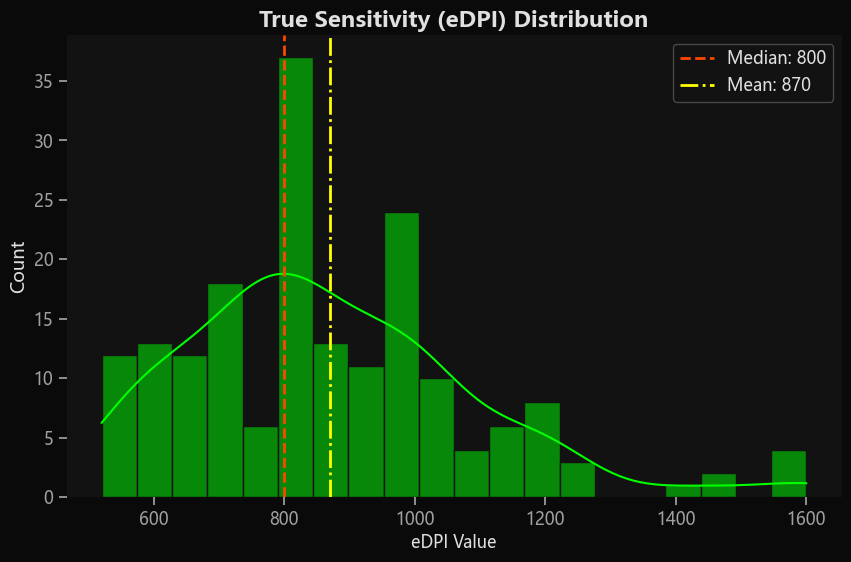

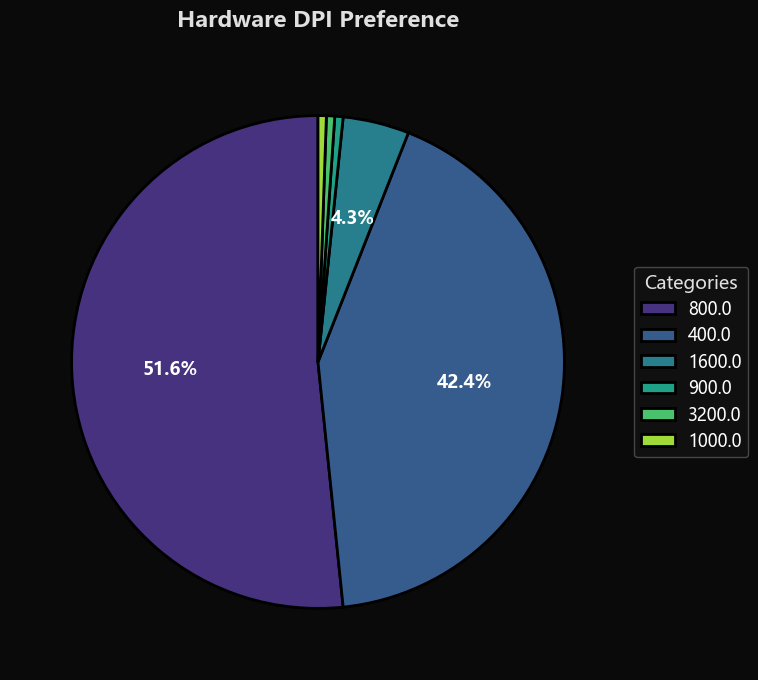

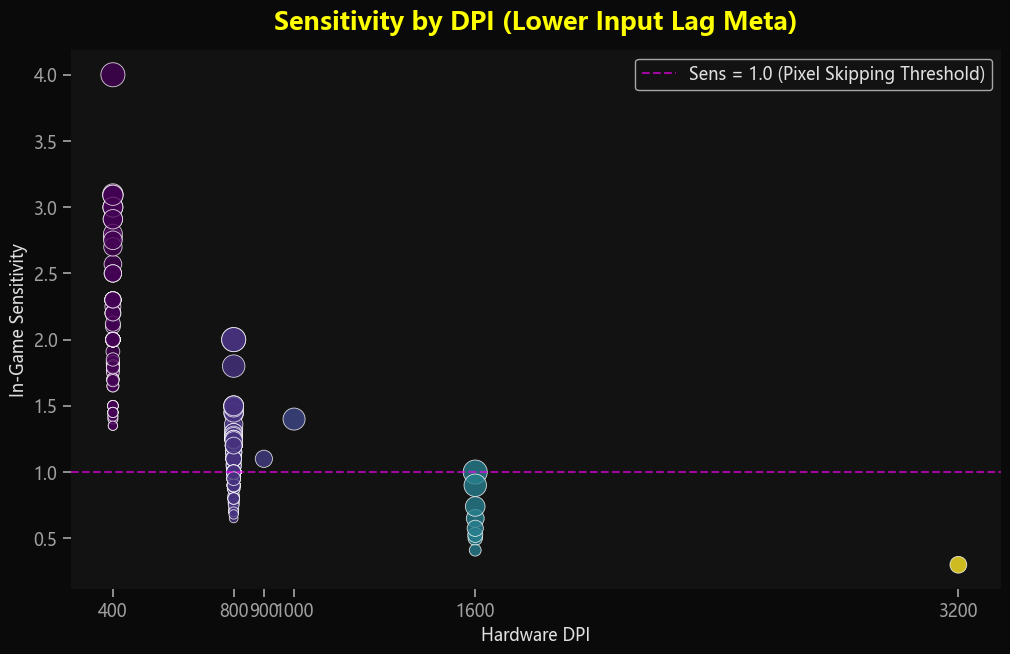

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 独立图 1：eDPI 宏观分布 ---
plt.figure(figsize=(10, 6))
plot_cs2_hist(plt.gca(), df_pro['eDPI'], title="True Sensitivity (eDPI) Distribution", color="#00FF00", show_stats=True)
plt.xlabel('eDPI Value', fontsize=12)
plt.show()

# --- 独立图 2：DPI 硬件偏好比例 (补上缺失的饼图！) ---
plt.figure(figsize=(8, 8))
dpi_counts = df_pro['DPI'].value_counts()
plot_cs2_pie(plt.gca(), dpi_counts, title='Hardware DPI Preference', palette_name='viridis')
plt.show()

# --- 独立图 3：DPI vs Sens 降维打击 ---
plt.figure(figsize=(12, 7))
ax = plt.gca()
sns.scatterplot(data=df_pro, x='DPI', y='Sensitivity', hue='DPI', palette='viridis', 
                size='eDPI', sizes=(40, 300), alpha=0.8, edgecolor='w', ax=ax, legend=False)
ax.axhline(1.0, color='#FF00FF', linestyle='--', alpha=0.6, label='Sens = 1.0 (Pixel Skipping Threshold)')
ax.set_title('Sensitivity by DPI (Lower Input Lag Meta)', fontsize=18, fontweight='bold', color='#FFFF00', pad=15)
ax.set_xlabel('Hardware DPI', fontsize=12)
ax.set_ylabel('In-Game Sensitivity', fontsize=12)
ax.set_xticks(sorted(df_pro['DPI'].dropna().unique()))
ax.legend(loc='upper right', facecolor='#121212')
sns.despine(ax=ax, left=True, bottom=True)
plt.show()

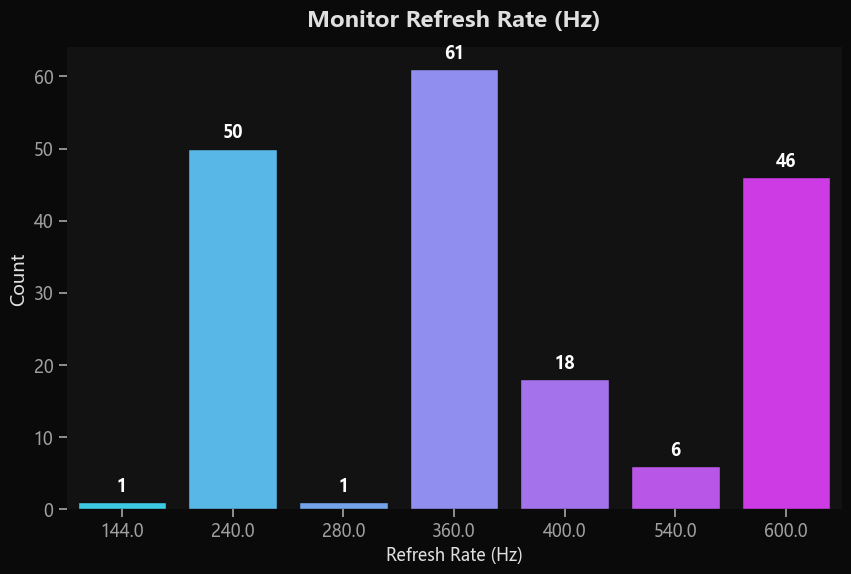

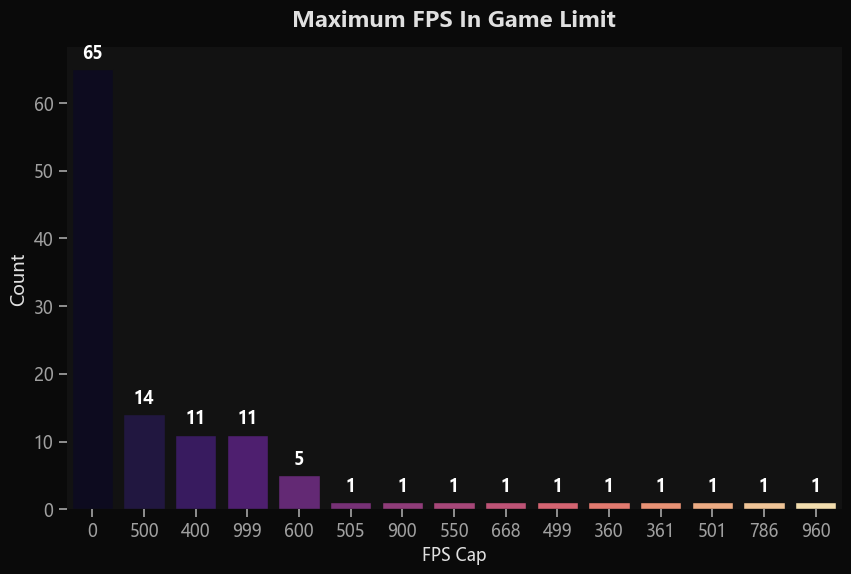

In [19]:
# --- 独立图 4：显示器刷新率 Hz ---
plt.figure(figsize=(10, 6))
if 'Hz_clean' not in df_pro.columns:
    df_pro['Hz_clean'] = df_pro['Hz'].astype(str).str.extract(r'(\d+)').astype(float)
hz_counts = df_pro.dropna(subset=['Hz_clean'])['Hz_clean'].value_counts().sort_index().reset_index()
hz_counts.columns =['Monitor Hz', 'Count']
plot_cs2_bar(plt.gca(), hz_counts, x_col='Monitor Hz', y_col='Count', title="Monitor Refresh Rate (Hz)", color_palette="cool")
plt.xlabel('Refresh Rate (Hz)', fontsize=12)
plt.show()

# --- 独立图 5：最高 FPS 限制 (找回你原本想做的上限图！) ---
plt.figure(figsize=(10, 6))
df_fps = df_pro[df_pro['Maximum FPS In Game'] != 'Unknown']
fps_counts = df_fps['Maximum FPS In Game'].value_counts().reset_index()
fps_counts.columns = ['Max FPS', 'Count']
plot_cs2_bar(plt.gca(), fps_counts, x_col='Max FPS', y_col='Count', title="Maximum FPS In Game Limit", color_palette="magma")
plt.xlabel('FPS Cap', fontsize=12)
plt.show()

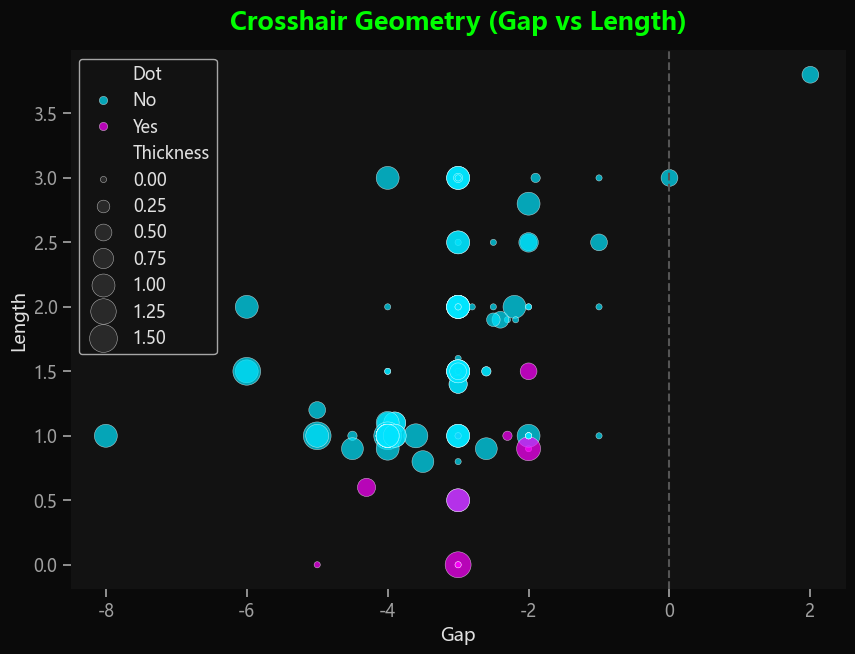

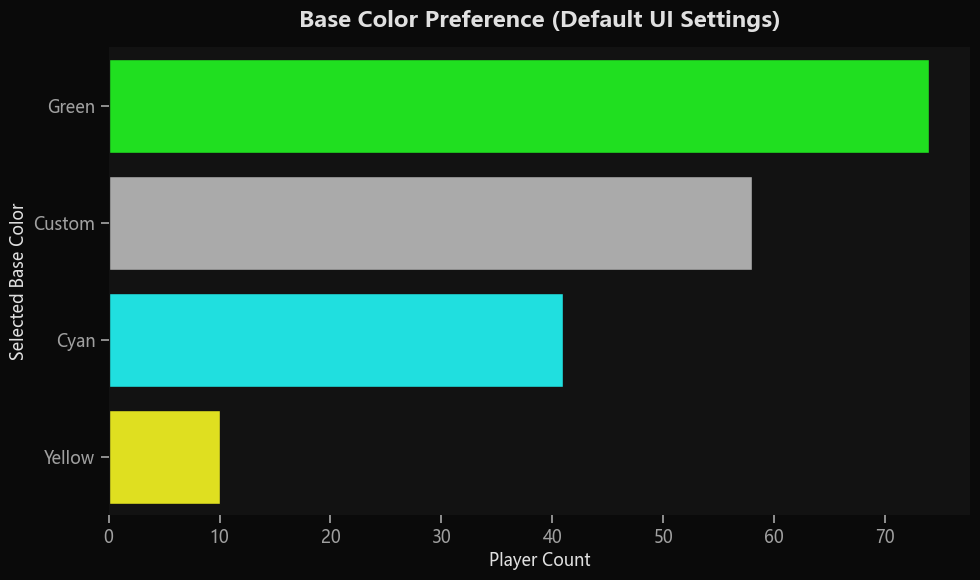

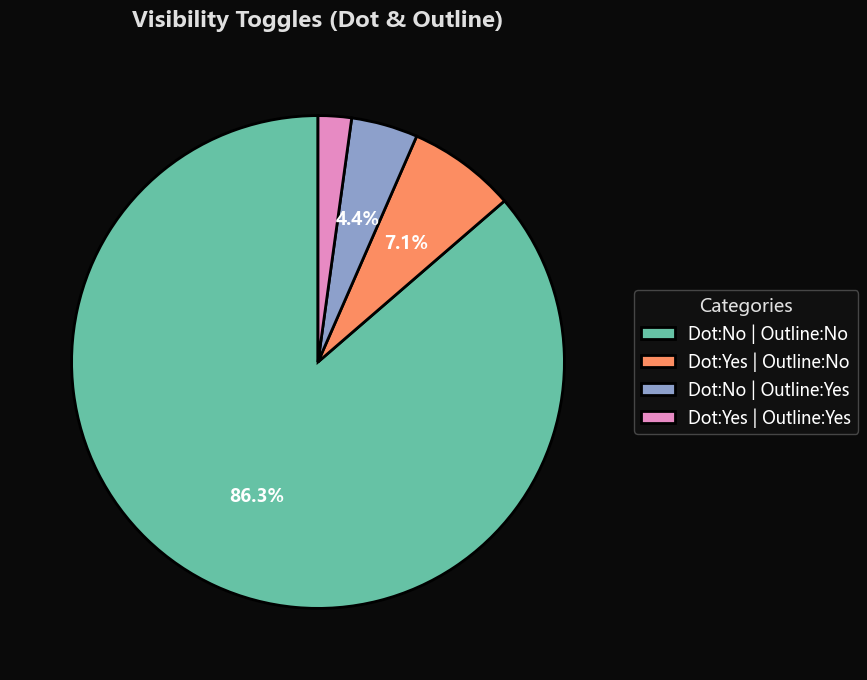

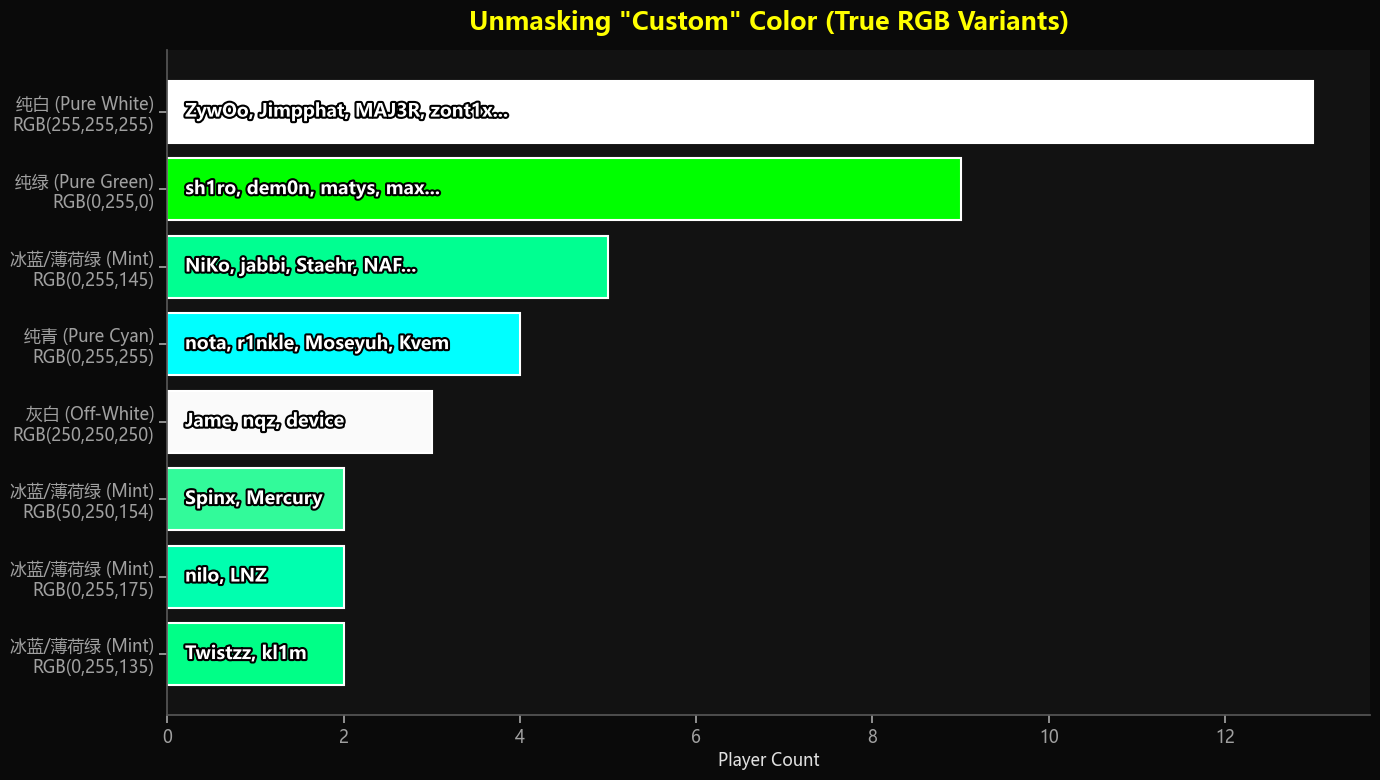

In [35]:
df_crosshair = df_pro.dropna(subset=['Gap', 'Length', 'Thickness', 'Color']).copy()

# --- 独立图 6：准星几何尺寸 (Gap vs Length) ---
plt.figure(figsize=(10, 7))
ax = plt.gca()
sns.scatterplot(data=df_crosshair, x='Gap', y='Length', size='Thickness', hue='Dot', 
                sizes=(20, 400), alpha=0.7, palette=['#00E5FF', '#FF00FF'], ax=ax, edgecolor='w')
ax.set_title('Crosshair Geometry (Gap vs Length)', fontsize=18, fontweight='bold', color='#00FF00', pad=15)
ax.axvline(0, color='#555555', linestyle='--')
sns.despine(ax=ax, left=True, bottom=True)
plt.show()

# --- 独立图 7：基础颜色选择 (语义匹配修复版) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 获取统计数据
color_counts = df_crosshair['Color'].value_counts().reset_index()
color_counts.columns = ['Color', 'Count']

# 🛑 核心修复：建立准确的“颜色语义字典”
base_color_map = {
    'Green': '#00FF00',    # 纯绿
    'Cyan': '#00FFFF',     # 纯青
    'Yellow': '#FFFF00',   # 亮黄
    'Red': '#FF0000',      # 纯红
    'Blue': '#0055FF',     # 深蓝
    'Pink': '#FF00FF',     # 亮粉
    'Light Blue': '#00A8FF', # 浅蓝
    'Custom': '#AAAAAA'    # 自定义(设为高级灰，因为重点在扒皮图里)
}

# 根据当前数据的排序，生成对应的真实 Hex 颜色列表
exact_palette =[base_color_map.get(c, '#888888') for c in color_counts['Color']]

# 调用你在 Cell 1 的工厂函数，传入真实的颜色列表！
plot_cs2_bar(plt.gca(), color_counts, x_col='Count', y_col='Color', 
             title='Base Color Preference (Default UI Settings)', 
             color_palette=exact_palette, orient='h')

plt.ylabel('Selected Base Color', fontsize=12)
plt.xlabel('Player Count', fontsize=12)

plt.tight_layout()
plt.show()

# --- 独立图 8：可见性开关 (Dot & Outline) ---
plt.figure(figsize=(8, 8))
df_crosshair['Toggle Config'] = 'Dot:' + df_crosshair['Dot'].astype(str) + ' | Outline:' + df_crosshair['Outline'].astype(str)
toggle_counts = df_crosshair['Toggle Config'].value_counts()
plot_cs2_pie(plt.gca(), toggle_counts, title='Visibility Toggles (Dot & Outline)', palette_name='Set2')
plt.show()

# --- 独立图 9：Custom 自定义 RGB 扒皮 (文字内嵌 & 描边终极版) ---
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patheffects as path_effects # 引入文字特效库！

plt.figure(figsize=(14, 8)) 
custom_df = df_pro[df_pro['Color'] == 'Custom'].dropna(subset=['Red', 'Green', 'Blue']).copy()

def rgb_to_hex(r, g, b):
    return '#{:02x}{:02x}{:02x}'.format(
        int(max(0, min(r, 255))), 
        int(max(0, min(g, 255))), 
        int(max(0, min(b, 255)))
    ).upper()

def get_color_name(r, g, b):
    if r==255 and g==255 and b==255: return "纯白 (Pure White)"
    if r==0 and g==255 and b==255: return "纯青 (Pure Cyan)"
    if r==255 and g==0 and b==255: return "亮粉 (Magenta)"
    if r==0 and g==255 and b==0: return "纯绿 (Pure Green)"
    if r==250 and g==250 and b==250: return "灰白 (Off-White)"
    if g>200 and r<100 and b<100: return "荧光绿 (Neon Green)"
    if g>200 and b>120 and r<100: return "冰蓝/薄荷绿 (Mint)"
    if r>200 and g>200 and b<100: return "亮黄 (Yellow)"
    return "混调色 (Custom Mix)"

custom_df['Hex_Color'] = custom_df.apply(lambda row: rgb_to_hex(row['Red'], row['Green'], row['Blue']), axis=1)
custom_df['Color_Name'] = custom_df.apply(lambda row: get_color_name(row['Red'], row['Green'], row['Blue']), axis=1)
custom_df['RGB_Label'] = custom_df['Color_Name'] + '\nRGB(' + custom_df['Red'].astype(int).astype(str) + ',' + custom_df['Green'].astype(int).astype(str) + ',' + custom_df['Blue'].astype(int).astype(str) + ')'

top_colors = custom_df.groupby(['RGB_Label', 'Hex_Color']).size().reset_index(name='Count').sort_values(by='Count', ascending=False).head(8).reset_index(drop=True)

ax = plt.gca()
ax.barh(top_colors['RGB_Label'], top_colors['Count'], color=top_colors['Hex_Color'], edgecolor='#FFFFFF', linewidth=1.5)
ax.invert_yaxis()

ax.set_title('Unmasking "Custom" Color (True RGB Variants)', fontsize=18, fontweight='bold', color='#FFFF00', pad=15)
ax.set_xlabel('Player Count', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 🌟 终极排版魔法：把名字写在色块最左边，并加上黑色描边护体！
for i, row in top_colors.iterrows():
    players = custom_df[custom_df['RGB_Label'] == row['RGB_Label']]['Player'].tolist()
    player_str = ", ".join(players[:4]) + ("..." if len(players)>4 else "")
    
    # 将 x 坐标固定在 0.2 (色块最左侧内部)
    txt = ax.text(0.2, i, player_str, 
                  va='center', ha='left', fontsize=13, color='white', style='italic', fontweight='bold')
    
    # 加上 3 像素的纯黑描边 (无论是白背景、绿背景还是黑背景，统统完美显示！)
    txt.set_path_effects([path_effects.withStroke(linewidth=3, foreground='#000000')])

plt.tight_layout()
plt.show()

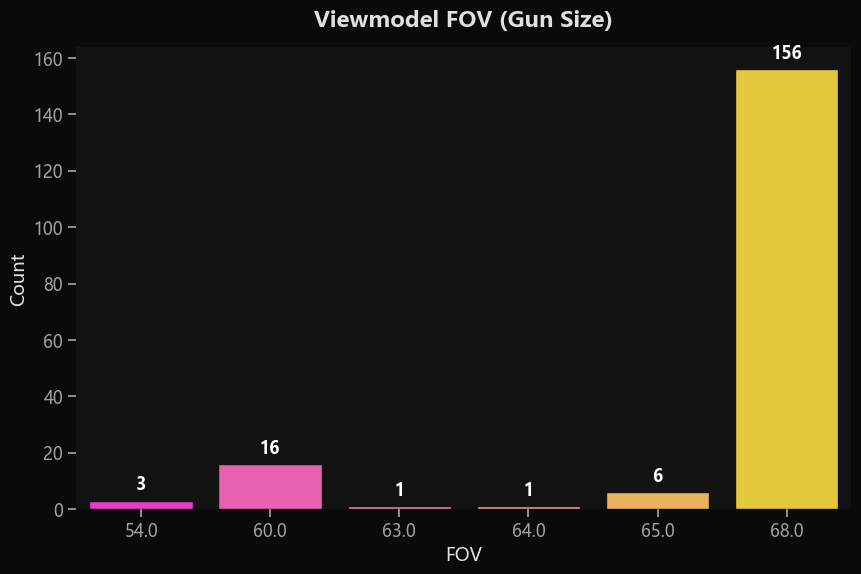

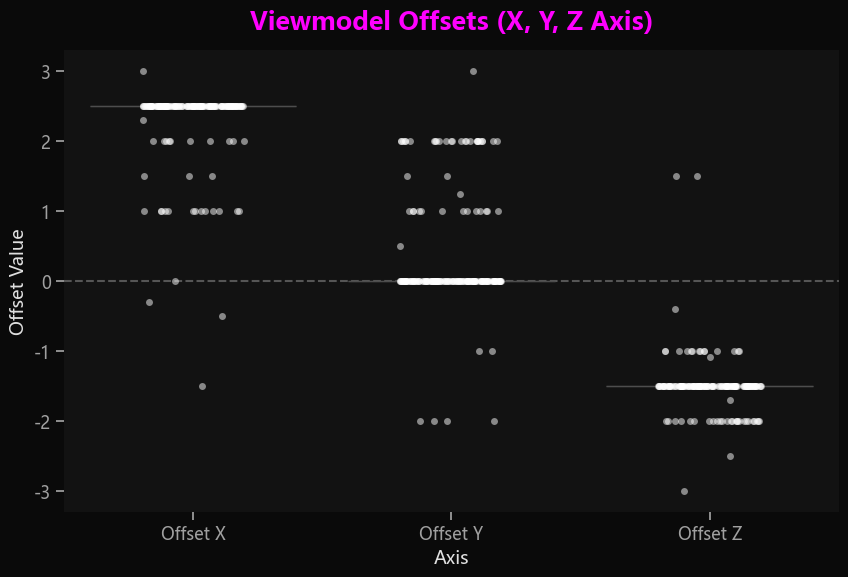

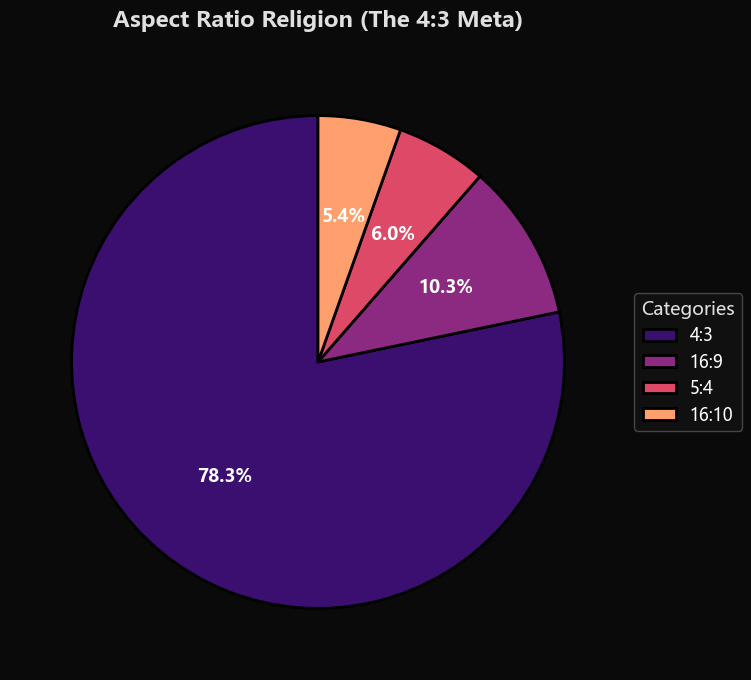

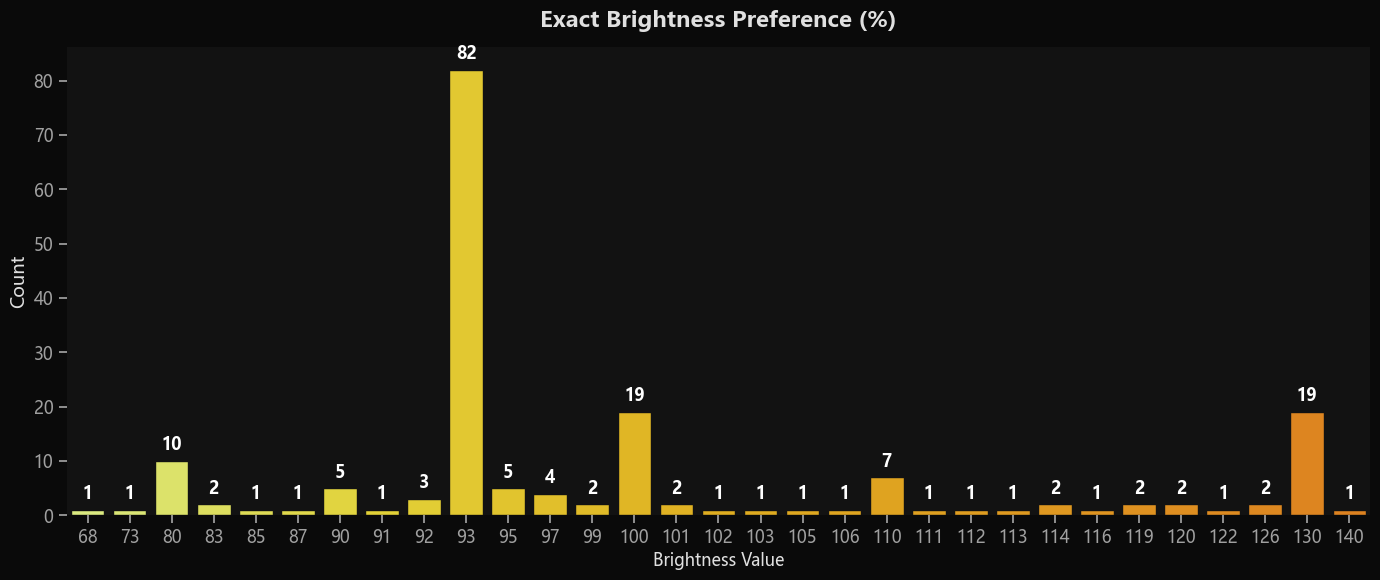

In [27]:
# --- 独立图 10：持枪视角 FOV ---
plt.figure(figsize=(10, 6))
df_fov = df_pro.dropna(subset=['FOV'])
fov_counts = df_fov['FOV'].value_counts().reset_index()
fov_counts.columns = ['FOV', 'Count']
plot_cs2_bar(plt.gca(), fov_counts, x_col='FOV', y_col='Count', title='Viewmodel FOV (Gun Size)', color_palette='spring')
plt.show()

# --- 独立图 11：持枪视角极限偏移 (藏枪学) ---
plt.figure(figsize=(10, 6))
ax = plt.gca()
offset_cols = ['Offset X', 'Offset Y', 'Offset Z']
df_offsets = df_pro[offset_cols].melt(var_name='Axis', value_name='Offset Value')
sns.boxplot(x='Axis', y='Offset Value', data=df_offsets, palette=['#00E5FF', '#00FF00', '#FF00FF'], boxprops=dict(alpha=0.6), showfliers=False, ax=ax)
sns.stripplot(x='Axis', y='Offset Value', data=df_offsets, color='white', alpha=0.5, jitter=0.2, size=5, ax=ax)
ax.axhline(0, color='#555555', linestyle='--')
ax.set_title('Viewmodel Offsets (X, Y, Z Axis)', fontsize=18, fontweight='bold', color='#FF00FF', pad=15)
sns.despine(ax=ax, left=True, bottom=True)
plt.show()

# --- 独立图 12：分辨率宽高比 (Aspect Ratio) ---
plt.figure(figsize=(8, 8))
ar_counts = df_pro['Aspect Ratio'].value_counts()
plot_cs2_pie(plt.gca(), ar_counts, title="Aspect Ratio Religion (The 4:3 Meta)", palette_name="magma")
plt.show()

# --- 独立图 13：亮度偏好 Brightness (去小数点纯净版) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6)) # 稍微加宽防拥挤
if 'Brightness_num' not in df_pro.columns:
    df_pro['Brightness_num'] = pd.to_numeric(df_pro['Brightness'].astype(str).str.replace('%', ''), errors='coerce')

df_bright = df_pro.dropna(subset=['Brightness_num']).copy()
# 强制转换为整数，干掉小数点！
df_bright['Brightness'] = df_bright['Brightness_num'].astype(int) 

bright_counts = df_bright['Brightness'].value_counts().sort_index().reset_index()
bright_counts.columns = ['Brightness', 'Count']

plot_cs2_bar(plt.gca(), bright_counts, x_col='Brightness', y_col='Count', title='Exact Brightness Preference (%)', color_palette='Wistia')
plt.xlabel('Brightness Value', fontsize=12)

plt.tight_layout()
plt.show()

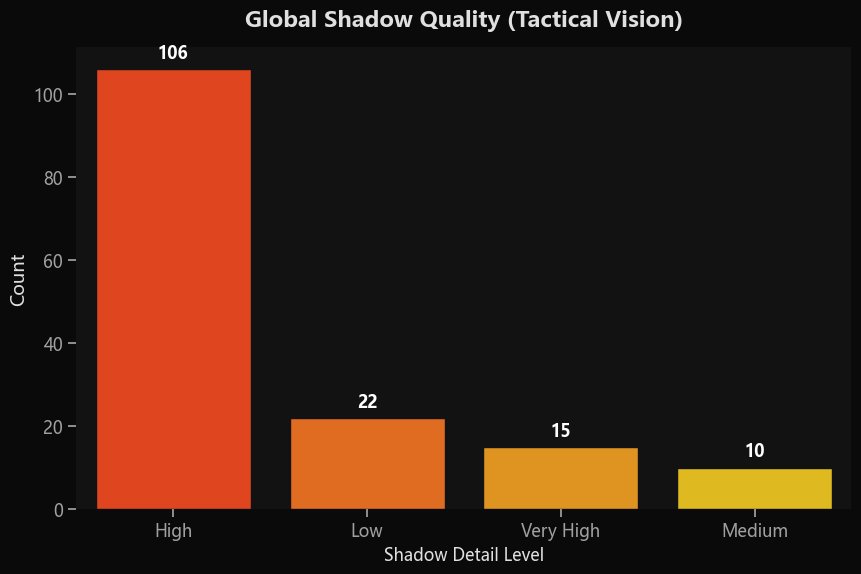

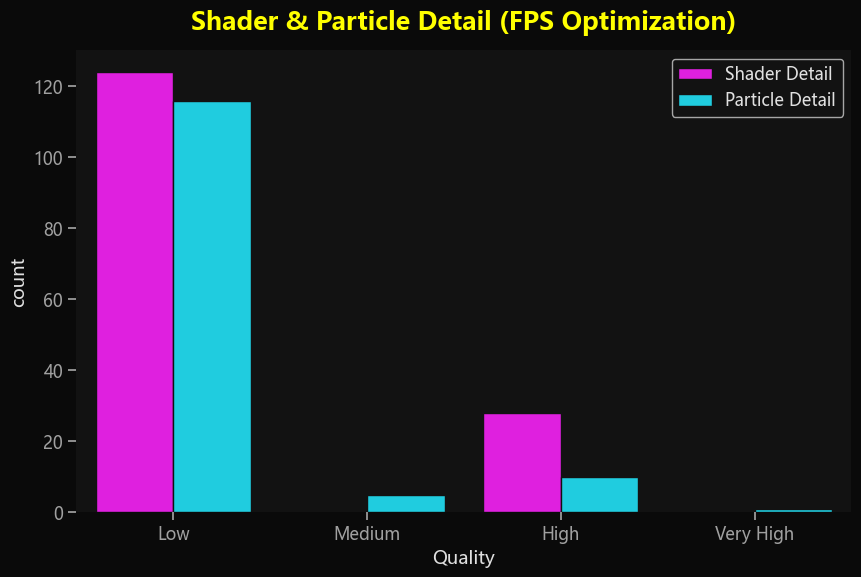

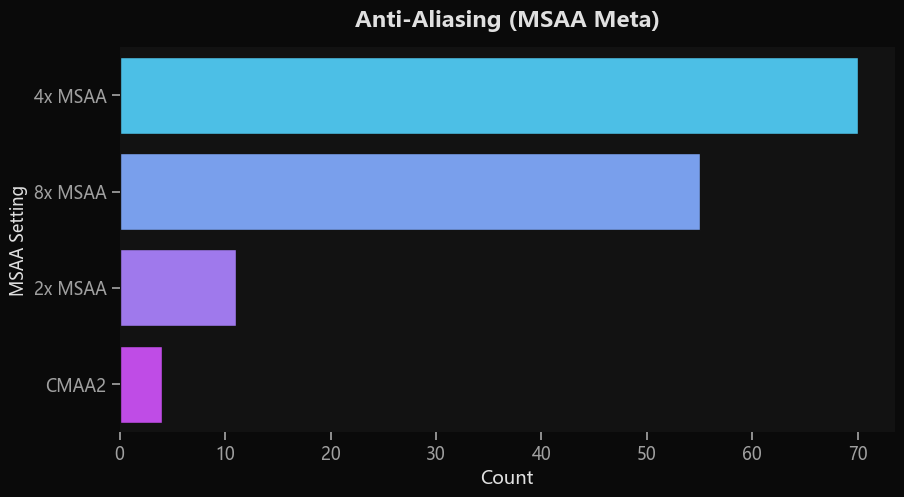

In [22]:
# --- 独立图 14：阴影质量 Shadow Quality ---
plt.figure(figsize=(10, 6))
shadow_counts = df_pro['Global Shadow Quality'].value_counts().reset_index()
shadow_counts.columns =['Quality', 'Count']
plot_cs2_bar(plt.gca(), shadow_counts, x_col='Quality', y_col='Count', title="Global Shadow Quality (Tactical Vision)", color_palette="autumn")
plt.xlabel('Shadow Detail Level', fontsize=12)
plt.show()

# --- 独立图 15：着色器与粒子细节 Shader & Particle ---
plt.figure(figsize=(10, 6))
ax = plt.gca()
df_shader_particle = df_pro[['Shader Detail', 'Particle Detail']].melt(var_name='Setting Type', value_name='Quality')
df_sp_clean = df_shader_particle[df_shader_particle['Quality'] != 'Unknown']
sns.countplot(data=df_sp_clean, x='Quality', hue='Setting Type', order=['Low', 'Medium', 'High', 'Very High'], palette=['#FF00FF', '#00E5FF'], ax=ax, edgecolor='#121212')
ax.set_title('Shader & Particle Detail (FPS Optimization)', fontsize=18, fontweight='bold', color='#FFFF00', pad=15)
ax.legend(facecolor='#121212')
sns.despine(ax=ax, left=True, bottom=True)
plt.show()

# --- 独立图 16：抗锯齿 MSAA ---
plt.figure(figsize=(10, 5))
df_msaa = df_pro[df_pro['Multisampling Anti-Aliasing Mode'] != 'Unknown'].copy()
msaa_counts = df_msaa['Multisampling Anti-Aliasing Mode'].value_counts().reset_index()
msaa_counts.columns = ['Mode', 'Count']
plot_cs2_bar(plt.gca(), msaa_counts, x_col='Count', y_col='Mode', title='Anti-Aliasing (MSAA Meta)', color_palette='cool', orient='h')
plt.ylabel('MSAA Setting', fontsize=12)
plt.show()

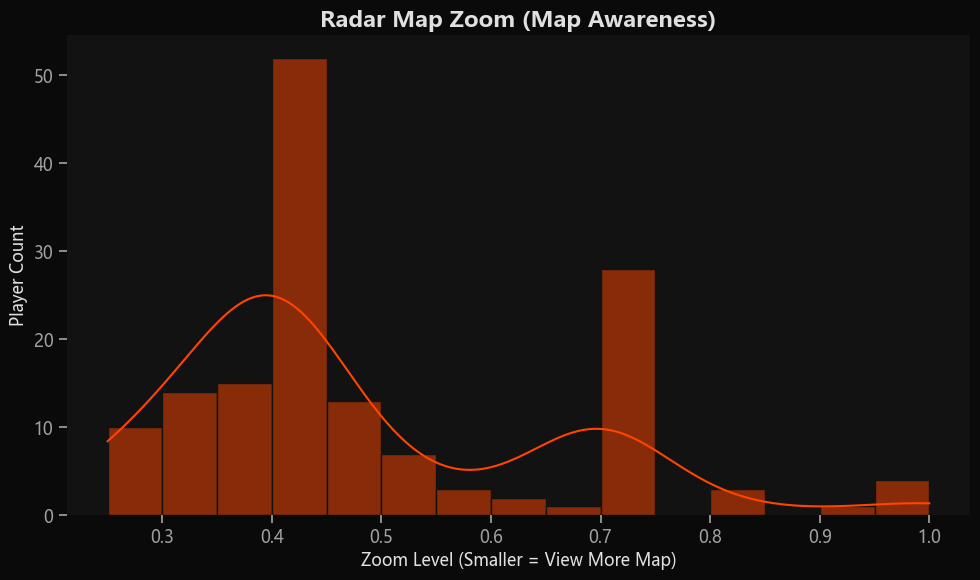

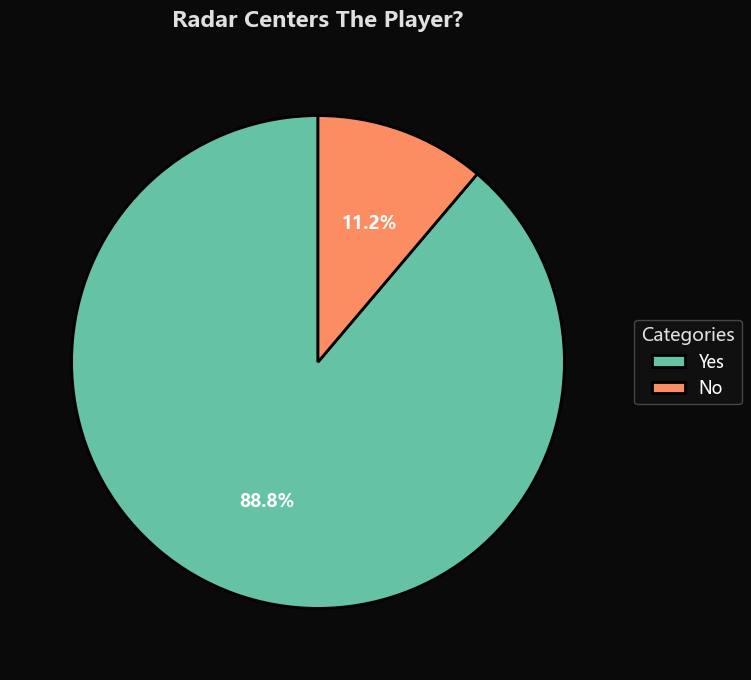

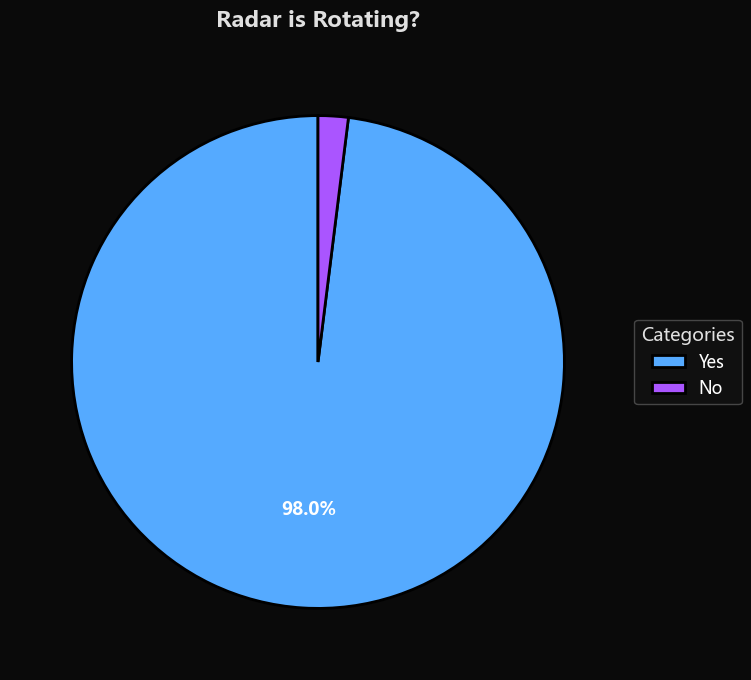

In [28]:
# --- 独立图 17：雷达缩放比例 Radar Zoom ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# 只需要把 show_stats=True 删掉即可！
plot_cs2_hist(plt.gca(), df_pro['Radar Map Zoom'].dropna(), title="Radar Map Zoom (Map Awareness)", color="#FF4500", bins=15)
plt.xlabel('Zoom Level (Smaller = View More Map)', fontsize=12)
plt.ylabel('Player Count', fontsize=12)

plt.tight_layout()
plt.show()

# --- 独立图 18：雷达玩家居中 Center Player ---
plt.figure(figsize=(8, 8))
center_counts = df_pro['Radar Centers The Player'].value_counts()
plot_cs2_pie(plt.gca(), center_counts, title="Radar Centers The Player?", palette_name="Set2")
plt.show()

# --- 独立图 19：雷达旋转 Radar Rotating ---
plt.figure(figsize=(8, 8))
rotate_counts = df_pro['Radar is Rotating'].value_counts()
plot_cs2_pie(plt.gca(), rotate_counts, title="Radar is Rotating?", palette_name="cool")
plt.show()

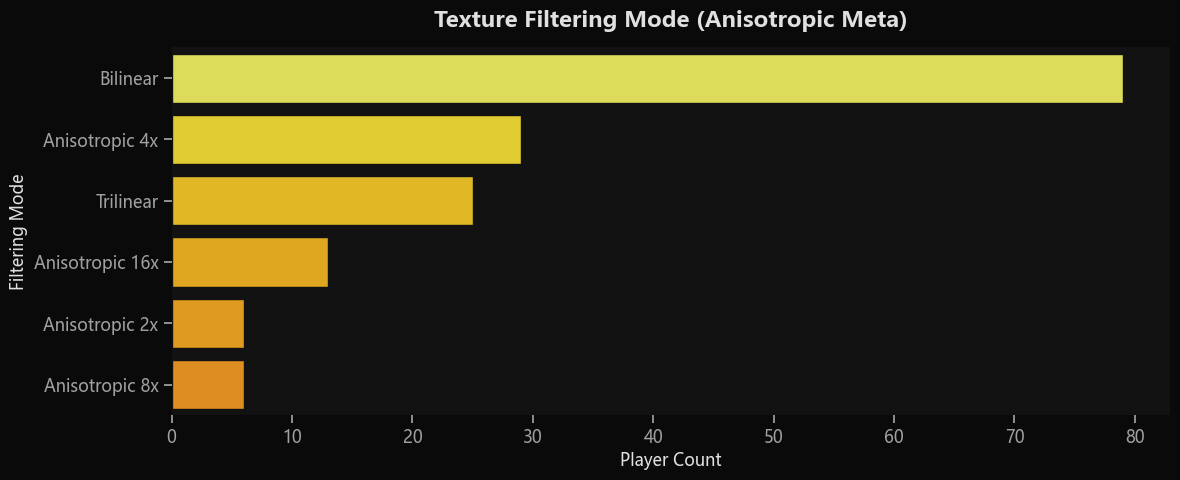

In [29]:
# --- 新增图 20：贴图过滤 (Texture Filtering Mode) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
df_texture = df_pro[df_pro['Texture Filtering Mode'] != 'Unknown'].copy()
texture_counts = df_texture['Texture Filtering Mode'].value_counts().reset_index()
texture_counts.columns = ['Mode', 'Count']

plot_cs2_bar(plt.gca(), texture_counts, x_col='Count', y_col='Mode', title='Texture Filtering Mode (Anisotropic Meta)', color_palette='Wistia', orient='h')
plt.ylabel('Filtering Mode', fontsize=12)
plt.xlabel('Player Count', fontsize=12)

plt.tight_layout()
plt.show()